In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit import QuantumCircuit, transpile
from quam_libs.components import QuAM
from quam_libs.experiments.qiskit_circuit import run_qiskit_to_qua_program, create_target
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

In [16]:
simulator = AerSimulator()

machine = QuAM.load()
n_shots = 1024
manual_transpile = True
target_qubit_indices = [0,1,2,3,4]
target_qubits = [machine.active_qubits[i] for i in target_qubit_indices]

for qubit in target_qubits:
    qubit.macros['reset'].reset_type='thermalize'
    qubit.macros['reset'].thermalize_time = qubit.thermalization_time


/Users/adamachuck/anaconda3/envs/QPX-Qualibrate/lib/python3.10/site-packages/quam/core/quam_classes.py:289: UserWarning: This component is not part of any QuamRoot, using last instantiated QuamRoot. This is not recommended as it may lead to unexpected behaviour. Component: TunableCoupler
  warnings.warn(


In [33]:
qc = QuantumCircuit(5, 5)
# qc.x(0)
# qc.x(1)
# qc.x(2)
# qc.x(3)
# qc.x(4)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.h(4)
# qc.cx(3, 4)
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)
qc.measure(3, 3)
qc.measure(4, 4)
# qc.measure_all()


{'10110': 23, '11010': 19, '00001': 25, '11100': 37, '11000': 28, '01011': 36, '10101': 32, '00101': 32, '10011': 41, '01110': 31, '10010': 37, '00111': 31, '10100': 29, '00010': 29, '11001': 27, '10000': 45, '01100': 34, '00100': 30, '01010': 39, '01101': 41, '10111': 31, '01001': 31, '11011': 30, '00000': 27, '01111': 26, '00011': 33, '01000': 40, '10001': 37, '11110': 25, '11101': 33, '00110': 33, '11111': 32}


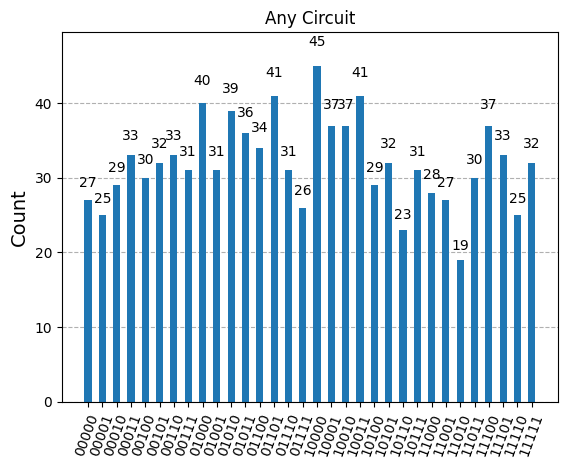

In [34]:
# Simulated QPU: 
circ = transpile(qc, simulator)

# Run and get counts
result = simulator.run(circ, n_shots=n_shots).result()
counts = result.get_counts(circ)
print(counts)
plot_histogram(counts, title='Any Circuit')

2025-10-28 22:29:02,594 - qm - INFO     - Performing health check
2025-10-28 22:29:02,600 - qm - INFO     - Cluster healthcheck completed successfully.
2025-10-28 22:29:02,808 - qm - INFO     - Clearing queue
2025-10-28 22:29:02,819 - qm - INFO     - Adding program to queue.


/Users/adamachuck/anaconda3/envs/QPX-Qualibrate/lib/python3.10/site-packages/qm/program/_qua_config_schema.py:1740: DeprecationWarning: thread is deprecated since "1.2.2" and will be removed in "1.3.0". Use 'core' instead.
  warnings.warn(deprecation_message("thread", "1.2.2", "1.3.0", "Use 'core' instead."), DeprecationWarning)
/Users/adamachuck/anaconda3/envs/QPX-Qualibrate/lib/python3.10/site-packages/qm/program/_qua_config_schema.py:1740: DeprecationWarning: thread is deprecated since "1.2.2" and will be removed in "1.3.0". Use 'core' instead.
  warnings.warn(deprecation_message("thread", "1.2.2", "1.3.0", "Use 'core' instead."), DeprecationWarning)
/Users/adamachuck/anaconda3/envs/QPX-Qualibrate/lib/python3.10/site-packages/qm/program/_qua_config_schema.py:1740: DeprecationWarning: thread is deprecated since "1.2.2" and will be removed in "1.3.0". Use 'core' instead.
  warnings.warn(deprecation_message("thread", "1.2.2", "1.3.0", "Use 'core' instead."), DeprecationWarning)
/Users/

{'c': {'00000': 55, '00001': 32, '00010': 40, '00011': 23, '00100': 35, '00101': 14, '00110': 41, '00111': 20, '01000': 47, '01001': 35, '01010': 49, '01011': 22, '01100': 29, '01101': 28, '01110': 34, '01111': 23, '10000': 55, '10001': 23, '10010': 43, '10011': 16, '10100': 36, '10101': 18, '10110': 49, '10111': 19, '11000': 40, '11001': 31, '11010': 44, '11011': 24, '11100': 31, '11101': 17, '11110': 35, '11111': 16}}


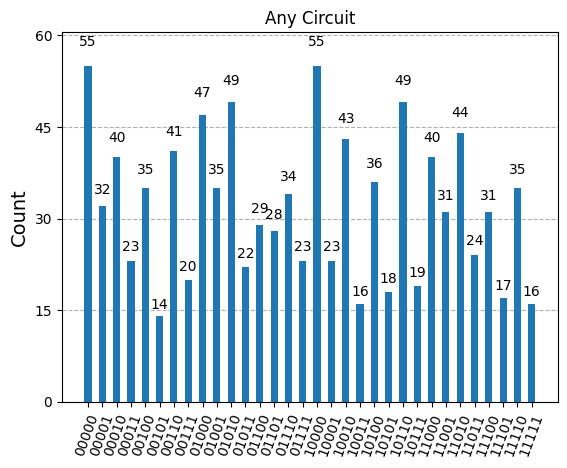

In [36]:
# Run on Real QPU: 
if manual_transpile:
    optimization_level = 1
    target = create_target(machine)
    # Transpile the circuit to the target (Optional: if not done here, will be done in the run_qiskit_to_qua_program function)
    qc = transpile(qc, target=target, initial_layout=target_qubit_indices, optimization_level=optimization_level)
    results = run_qiskit_to_qua_program(qc, machine, n_shots=n_shots)

else:
    optimization_level = 1 # Default optimization level is 1, has to be specified if manual_transpile is False
    results = run_qiskit_to_qua_program(qc, machine, target_qubits, n_shots, optimization_level)

print(results)
plot_histogram(results['c'], title='Any Circuit')

# Results in the form: {'c1": {"00": 512, "11": 512}, "c0": {"00": 512, "11": 512}, ...}